# **데이터 전처리 - 이상치처리, Feature Engineering**

- 데이터 분석/AI 모델링을 위하여 데이터를 정제하는 전처리 과정은 아래와 같습니다.
    - 첫번째, 데이터 탐색하기
    - 두번째, 결측치 처리하기
    - 세번째, 이상치 처리하기
    - 네번째, Feature Engineering 

- 데이터 전처리 , 두번째 파트로  이상치 처리하기와 Feature Engineering에 대해서 배워 보도록 하겠습니다.

<br>

## **0. 필요 라이브러리와 데이터 불러오기**

In [1]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np

# warning 경고 제거하기
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 판다스 옵션을 사용해서 화면에 보기 좋기 보이게 하기

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option("display.max_columns", 999)

In [3]:
# cust_data1.csv 데이터 파일을 읽고 cust 데이터프레임에 저장합니다.
cust = pd.read_csv("cust_data.csv")

In [4]:
# "cust_data1.csv" 파일을 읽은 cust 데이터프레임을 실습을 위해 cust_fix 데이터프레임으로 백업합니다. 
cust_fix = cust.copy()

In [5]:
# 저장된 cust 데이터프레임 확인하기
cust

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N
...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.00,1,N,N,1860.00,1716.00,0.00,N
8224,C,F,15.00,1,N,Y,1296.10,194.41,643.10,N
8225,G,M,12.00,1,N,N,13799.67,2069.95,10605.93,N
8226,C,F,40.00,0,N,N,3140.00,942.00,1884.00,Y


In [6]:
# cust 데이터프레임에 대한 전체 정보 확인하기
cust.info()

<class 'pandas.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8228 non-null   str    
 1   sex          8228 non-null   str    
 2   age          8228 non-null   float64
 3   service      8228 non-null   int64  
 4   stop         8228 non-null   str    
 5   npay         8228 non-null   str    
 6   avg_bill     8228 non-null   float64
 7   A_bill       8228 non-null   float64
 8   B_bill       8228 non-null   float64
 9   termination  8228 non-null   str    
dtypes: float64(4), int64(1), str(5)
memory usage: 642.9 KB


<br>

## **1. 이상치 처리하기**
- 이상치는 특정 추세에서 크게 벗어난 데이터나 중앙값을 크게 벗어난 데이터를 의미 합니다.
- 이상치 처리시 이상치 삭제나 대체하는 방법을 사용합니다.

<br>

### **범주형 데이터 이상치 처리 하기**
범주형 데이터의 경우 value_counts 메소드를 사용하면, 값의 분포와 함께 Trash 값이 있는지도 확인 가능합니다.

In [7]:
# value_counts 함수를 이용해서 성별(sex) 범주형 데아터의 값 분포 확인하기
cust['sex'].value_counts()

sex
M    4432
F    3796
Name: count, dtype: int64

In [8]:
# value_counts 함수를 이용해서 미납여부(npay) 범주형 데아터의 값 분포 확인하기
cust['npay'].value_counts()

npay
N    7259
Y     969
Name: count, dtype: int64

In [9]:
# value_counts 함수를 이용해서 등급(class) 범주형 데아터의 값 분포 확인하기
cust['class'].value_counts()

class
D    2181
G    2038
C    1913
E    1244
F     711
H     141
Name: count, dtype: int64

Class의 값에는 'C, D, E, F, G, H'가 들어있는것을 확인할수 있습니다.    
실제로 그렇지는 않지만 'H'가 실제로는 존재하지 않는 값이라고 가정해 봅시다.    
**이상치를 처리하는 방법은 제거하기와 변경하기가 있습니다.**

In [10]:
# class컬럼의 'H' 값을 이상치로 생각하고 이상치 제거해 보겠습니다. 
# 이상치 제거시 Boolean indexing을 활용해서 class 컬럼의 값이 'H' 아닌것만 추출하면 되겠습니다. 
# 먼저, class 컬럼의 값이 'H' 아닌것만 추출하도록 조건문 만들기

cust['class'] != 'H'

0       True
1       True
2       True
3       True
4       True
        ... 
8223    True
8224    True
8225    True
8226    True
8227    True
Name: class, Length: 8228, dtype: bool

In [11]:
# cust 데이터프레임에 위에서 만든 조건문 적용하고 
# 이상치 제거 결과를 다시 cust 데이터프레임에 적용해 보겠습니다.

cust = cust[ cust['class'] != 'H' ]

In [12]:
# value_counts 함수를 이용해서 'H' 등급(class)이 제거되었음을 확인할수 있습니다.
cust['class'].value_counts()

class
D    2181
G    2038
C    1913
E    1244
F     711
Name: count, dtype: int64

In [13]:
# 다시 이상치 실습을 위해 copy() 함수를 사용하여 복사해 놓은 cust_fix을 cust_data 데이터프레임으로 복사합니다.
cust_data = cust_fix.copy()

In [14]:
# value_counts 함수를 이용해서 등급(class) 범주형 데아터의 값 분포 확인하기
# 'H' 등급이 141개 있음을 알수 있습니다.  

cust_data['class'].value_counts()

class
D    2181
G    2038
C    1913
E    1244
F     711
H     141
Name: count, dtype: int64

In [15]:
# 이번에는 class컬럼의 'H' 값을 이상치로 생각하고 다른값으로 변경해 보겠습니다. 
# replace 함수를 사용해서 class컬럼의 'H' 이상치 값을 'F'값으로 변경해 보겠습니다. 

cust_data['class'] = cust_data['class'].replace('H','F')

In [16]:
# 다시 value_counts 함수를 이용해서 'H' 등급(class)이 제거되었고, 
# 'F' 등급의 건수가 늘어난걸 확인할수 있습니다.

cust_data['class'].value_counts()

class
D    2181
G    2038
C    1913
E    1244
F     852
Name: count, dtype: int64

<br>

### <b>수치형 데이터 이상치 처리 하기</b>
describe 함수를 사용해서 수치형 변수의 기술 통계를 확인 할 수 있습니다.

In [17]:
cust_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8228 non-null   str    
 1   sex          8228 non-null   str    
 2   age          8228 non-null   float64
 3   service      8228 non-null   int64  
 4   stop         8228 non-null   str    
 5   npay         8228 non-null   str    
 6   avg_bill     8228 non-null   float64
 7   A_bill       8228 non-null   float64
 8   B_bill       8228 non-null   float64
 9   termination  8228 non-null   str    
dtypes: float64(4), int64(1), str(5)
memory usage: 642.9 KB


In [18]:
# cust_data 데이터프레임의 연속형 컬럼에 대해서 기술적 통계 확인해 보겠습니다.
# 연속형 컬럼에 대한 통계정보를 확인할수 있습니다.
# - 개수, 평균, 표준편차, 최소값, 1분위값(Q1), 중앙값(2분위값), 3분위값(Q3), 최대값
# age 컬럼의 최소값은 4, 최대값 104 입니다. 
# avg_bill 컬럼의 최소값 299, 최대값 144,739 입니다. 
# age 컬럼과 avg_bill 컬럼과의 숫자 사이즈가 차이가 많이 발생하고 있습니다. > 스케일링 필요

cust_data.describe()

,age,service,avg_bill,A_bill,B_bill
count,8228.00,8228.00,8228.00,8228.00,8228.00
mean,47.88,1.23,10356.61,1764.51,5630.46
std,19.26,0.80,8394.57,2599.85,4380.13
min,4.00,0.00,299.90,0.00,0.00
25%,32.00,1.00,4725.60,386.15,2385.36
50%,49.00,1.00,9396.62,1665.00,5404.77
75%,61.00,1.00,14322.58,2325.56,8434.98
max,104.00,14.00,144739.69,131581.53,65836.56


### **연속형 데이터에 대한 boxplot 그래프로 이상치 확인하기** 

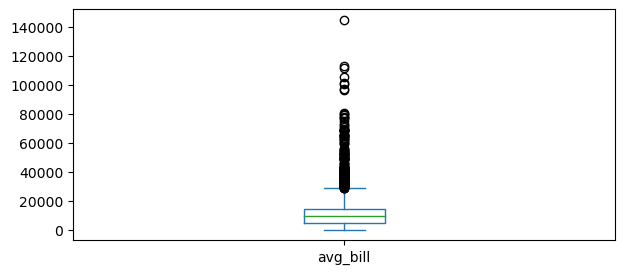

In [78]:
# matplotlib 활용하여 박스 플랏 시각화
# 박스 플랏 그래프를 보니 , 굉장히 큰값들이 존재하는걸로 보입니다. 

import matplotlib.pyplot as plt

plt.figure(figsize=(7,3))
cust_data['avg_bill'].plot(kind='box')
plt.show()

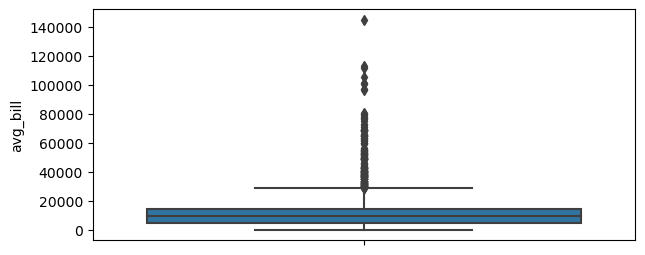

In [79]:
# seaborn 활용하여 박스 플랏 시각화
# 박스 플랏 그래프를 보니 , 굉장히 큰값들이 존재하는걸로 보입니다. 

import seaborn as sns

plt.figure(figsize=(7,3))
sns.boxplot(data=cust_data, y='avg_bill')
plt.show()

<br>

### **연속형 데이터에 대한 IQR 계산해서 이상치 확인하기**     
Q1와 Q3가 거리의 1.5배가 넘어가는 값을 Outlier 라고 합니다. 즉,       
Q3 - Q1 = IQR   
Q1 - 1.5 * IQR (Lower Fence)보다 작은 값들과 Q3 + 1.5 * IQR (Upper Fence)보다 큰 값들을 이상치(Outlier)라고 합니다.   
이 값들은 이상치로써 제거 또는 변경하여 데이터를 분석,학습 할수 있으나,    
때에 따라서는 이상치라고 해서 제거나 변경하지 않고 진행하는 경우도 많습니다.    
도메인전문가와 협의해서 이상치와 처리여부에 대해 협의하시기 바랍니다.  

In [80]:
# 위의 공식을 적용하여 이상치를 제거하는 함수 만들어 보겠습니다.

def removeOutliers(df, column):
    
    # Q1, Q3구하기
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    
    # 1.5 * IQR(Q3 - Q1)
    iqr = 1.5 * (q3 - q1)
    
    # 이상치를 제거 : 이상치가 아닌 정상인 값들만 수집함
    y = df[ ( df[ column ] < (q3 + iqr) ) & ( df[ column ] > (q1 - iqr) ) ]
    
    return(y)

In [81]:
# 위의 removeOutliers 함수를 활용해서 'avg_bill' 연속형 컬럼에 대해 이상치 제거해 보겠습니다. 
cust_data = removeOutliers(cust_data, 'avg_bill')

In [82]:
# avg_bill 컬럼에 대한 이상치를 제거후 avg_bill 컬럼에 대한 전후 통계 비교해 보겠습니다.
# 이상치 제거전 :  avg_bill 컬럼의 최대값 144,739
# 이상치 제거후 : avg_bill 컬럼의  최대값 28,649 --> 최대값의 변경 있음!!

cust_data.describe()

,age,service,avg_bill,A_bill,B_bill
count,8066.00,8066.00,8066.00,8066.00,8066.00
mean,48.08,1.22,9583.54,1652.91,5474.78
std,19.30,0.79,5823.99,1590.70,4086.68
min,4.00,0.00,299.90,0.00,0.00
25%,33.00,1.00,4649.19,358.65,2302.00
50%,49.00,1.00,9199.10,1654.06,5305.61
75%,62.00,1.00,14001.67,2296.35,8281.07
max,104.00,14.00,28649.30,19698.53,19965.38


In [83]:
# 동일한 함수로 나머지 연속형 변수에 대해서도 이상치를 제거해 보겠습니다.
# A_bill : 이상치 제거전 최대값 131,581 , 이상치 제거후 최대값 5,190
# B_bill : 이상치 제거전 최대값 658,36 , 이상치 제거후 최대값 17,034
# 자주 사용하는 코딩에 대해 함수로 만들어 사용하시면 반복 수작업을 제거할수 있습니다.
# removeOutliers 함수를 여러번 수행하게 되면, 계속해서 outlier 이상치를 삭제하게 되어 통계 수치가 변경됩니다. 

cust_data=removeOutliers(cust_data, 'A_bill')
cust_data=removeOutliers(cust_data, 'B_bill')
cust_data.describe()

,age,service,avg_bill,A_bill,B_bill
count,7814.00,7814.00,7814.00,7814.00,7814.00
mean,48.08,1.19,9386.91,1483.58,5440.97
std,19.38,0.72,5724.55,1091.18,3970.95
min,4.00,0.00,299.90,0.00,0.00
25%,33.00,1.00,4435.20,342.00,2384.75
50%,49.00,1.00,9028.10,1615.87,5308.10
75%,62.00,1.00,13766.82,2238.00,8204.87
max,104.00,9.00,28649.30,5190.53,17034.60


In [84]:
# 연속형 변수에 대해서 이상치를 제거하니, 전체건수가 8,228 --> 7,814건으로 줄어 들었습니다. 
cust_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7814 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        7814 non-null   object 
 1   sex          7814 non-null   object 
 2   age          7814 non-null   float64
 3   service      7814 non-null   int64  
 4   stop         7814 non-null   object 
 5   npay         7814 non-null   object 
 6   avg_bill     7814 non-null   float64
 7   A_bill       7814 non-null   float64
 8   B_bill       7814 non-null   float64
 9   termination  7814 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 671.5+ KB


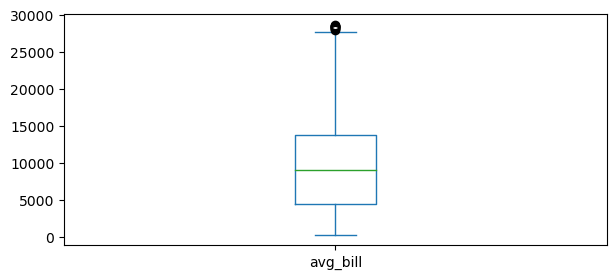

In [85]:
# matplotlib 활용하여 박스 플랏 시각화
# 박스 플랏 그래프를 보니 , 이상치 제거된걸 확인할수 있습니다. 

import matplotlib.pyplot as plt

plt.figure(figsize=(7,3))
cust_data['avg_bill'].plot(kind='box')
plt.show()

In [86]:
# 이번에는 이상치를 Lower Fence, Upper Fence로 변경하는 함수 만들기

def changeOutliers(df, column):
    
    # Q1, Q3구하기
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    
    # 1.5 * IQR(Q3 - Q1)
    iqr = 1.5 * (q3 - q1)
    
    #이상치 대체값 설정하기
    Min = 0
    if (q1 - iqr) > 0 : 
        Min = (q1 - iqr)
        
    Max = q3 + iqr
    
    # 이상치를 변경
    df.loc[ ( df[column] > Max ), column] = Max
    df.loc[ ( df[column] < Min ), column] = Min
    
    return(df)

In [87]:
# 앞에서 만든 changeOutliers 함수를 활용하여 avg_bill 연속형 컬럼의 이상치 변경하기
# 이전의 avg_bill 최대값 28649.30 --> 함수적용 후 avg_bill 최대값 27764.24

cust_data=changeOutliers(cust_data, 'avg_bill')
cust_data.describe()

,age,service,avg_bill,A_bill,B_bill
count,7814.00,7814.00,7814.00,7814.00,7814.00
mean,48.08,1.19,9386.24,1483.58,5440.97
std,19.38,0.72,5722.37,1091.18,3970.95
min,4.00,0.00,299.90,0.00,0.00
25%,33.00,1.00,4435.20,342.00,2384.75
50%,49.00,1.00,9028.10,1615.87,5308.10
75%,62.00,1.00,13766.82,2238.00,8204.87
max,104.00,9.00,27764.24,5190.53,17034.60


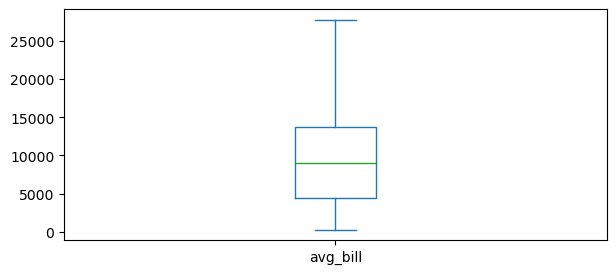

In [88]:
# matplotlib 박스 플랏 시각화
# 박스 플랏 그래프를 보니 , 이상치가 완전히 제거된걸 확인할수 있습니다. 

import matplotlib.pyplot as plt

plt.figure(figsize=(7,3))
cust_data['avg_bill'].plot(kind='box')
plt.show()

In [89]:
# changeOutliers 함수로 나머지 연속형 변수에 대해서도 이상치를 처리해 보겠습니다.
# 자주 사용하는 작업을 함수로 만들면 코딩하는데 편하게 할수 있습니다.  

cust_data=changeOutliers(cust_data, 'A_bill')
cust_data=changeOutliers(cust_data, 'B_bill')
cust_data.describe()

,age,service,avg_bill,A_bill,B_bill
count,7814.00,7814.00,7814.00,7814.00,7814.00
mean,48.08,1.19,9386.24,1483.49,5440.94
std,19.38,0.72,5722.37,1090.86,3970.88
min,4.00,0.00,299.90,0.00,0.00
25%,33.00,1.00,4435.20,342.00,2384.75
50%,49.00,1.00,9028.10,1615.87,5308.10
75%,62.00,1.00,13766.82,2238.00,8204.87
max,104.00,9.00,27764.24,5082.00,16935.03


<br>

## **2. Feature Engineering**
모델 정확도를 높이기 위해서 주어진 데이터를 잘 표현할 수 있는 features로 변형시키는 과정이며   
데이터의 도메인 지식을 활용해 feature를 만드는 과정입니다.    

In [90]:
# 퓨쳐 엔지니어링을 하기전에 다시 cust 데이터프레임을 확인해 봅시다.
cust_data.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N


<br>

### <b>Binning</b>
Binning은 단어 뜻 그대로 자료를 일정한 규격의 통에 넣는것 입니다.    
연속형 데이터를 범위(구간)를 나누어 범주형 데이터로 만든다고 생각하시면 됩니다.  
이렇게 해서 연속형 데이터를 구간별로 나눠 범주형 데이터를 새로 만들수 있습니다.    
이게 바로 Feature Engineering 예제입니다.

In [91]:
# Feature Engineering 예제로 
# age 컬럼을 활용하여 나이대("by_age") 컬럼을 새로 만들어 보겠습니다. 
# 나이 값 // 10 하면 몫만 나오게 되며 거기에 곱하기 10을 하면 10, 20, 30 처럼 나오게 됩니다.
# 10.0, 20.0 처럼 실수값으로 나오므로, astype 함수를 활용해서 정수형으로 변경합니다. 

cust_data[ 'by_age' ] = cust_data[ 'age' ] // 10 * 10
cust_data = cust_data.astype( { 'by_age' : int } )

In [92]:
# 새로운 'by_age' 컬럼이 생성되었으며, 기존 age 컬럼의 값을 10, 20, 30 대로 범주형 컬럼으로 변경했습니다.
# 이렇듯이 기존 데이터를 가지고 새로운 컬럼을 만들어 내는것이 feature engineering의 예 입니다. 

cust_data.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y,20
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N,20
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N,30
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N,10
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N,70


#### **cut**
Cut 함수를 사용하면 사용자가 구간을 지정해서 쉽게 범주화 할 수 있습니다.    
연속형 데이터를 구간 구간으로 나누어 범주화하고 범주마다 Label을 지정하게 됩니다.

In [93]:
# 이번에는 3개월 평균 요금 (avg_bill) 컬럼에 대해서 , 최소, 1분위, 3분위, 최대로 구간을 나누도록 해 보겠습니다.
# 먼저, 3개월 평균 요금 (avg_bill) 컬럼에 대한 1분위값과 3분위값을 먼저 파악해 보겠습니다.
# quantile() 함수를 활용하면 1분위, 3분위 값을 쉽게 알수가 있습니다. 

q1 = cust_data[ 'avg_bill' ].quantile(0.25)
q3 = cust_data[ 'avg_bill' ].quantile(0.75)
print(q1, q3)

4435.2000275 13766.8167


In [94]:
# cut 함수를 활용하여 3개월 평균 요금 (avg_bill) 을 3개 구간, low, mid, high 으로 나누어 보겠습니다.
# 3개월 평균 요금 (avg_bill) 을 low, mid, high 구간으로 나누고 'bill_rating' 새로운 컬럼에 저장하겠습니다.

cust_data[ 'bill_rating' ] = pd.cut( cust_data[ "avg_bill" ], 
                                   bins=[ 0, q1, q3, cust_data[ "avg_bill" ].max() ], 
                                   labels=[ 'low', 'mid','high' ] )

In [95]:
# cut 함수 적용 결과를 확인해 보겠습니다. 
# bill_rating 새로운 컬럼이 생성되었으며, low, mid, high 값으로 구성되어 잇음을 확인할수 있습니다.

cust_data.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age,bill_rating
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y,20,low
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N,20,high
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N,30,high
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N,10,mid
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N,70,low


In [96]:
# bill_rating 범주형 컬럼에 대한 분포를 확인해 보겠습니다. 
cust_data[ 'bill_rating' ].value_counts()

bill_rating
mid     3906
low     1954
high    1954
Name: count, dtype: int64

#### **qcut**
cut비슷하지만 구간의 갯수를 주면 알아서 같은 크기로 구간의 갯수로 나누어 주게 됩니다.

In [97]:
# cut 함수와 다르게 qcut 함수는 구간의 갯수만 나열하면 알아서 동일한 크기의 구간을 만들어 주게 됩니다.
# qcut 함수를 활용하여 3개월 평균 요금 (avg_bill)을 3개의 동일 구간으로 나누어 보겠습니다.
# cut와 마찬가지로 bill_rating 컬럼의 값들이 lov, mid, high 값으로 보이게 됩니다. 

cust_data[ 'bill_rating' ] = pd.qcut( cust_data[ "avg_bill" ], 3 , labels=[ 'low', 'mid','high' ] )
cust_data.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age,bill_rating
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y,20,low
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N,20,high
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N,30,high
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N,10,low
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N,70,low


In [98]:
# qcut 함수 적용된 bill_rating 컬럼의 분포를 확인해 보면
# low, mid, high의 분포가 똑같은것을 확인할수 있습니다. 

cust_data[ 'bill_rating' ].value_counts()

bill_rating
low     2605
high    2605
mid     2604
Name: count, dtype: int64

<br>

### <b>Scaling
각 컬럼에 들어있는 데이터의 상대적 크기에 따라 분석 결과나 모델링 결과가 달라질수 있습니다.    
0 ~ 1000까지의 값을 가지는 변수 A와 0 ~ 10까지의 값을 가지는 변수 B를 가지고 분석을 수행하면 상대적으로 큰 숫자를 가지는 A변수의 영향이 더 크게 반영 됩니다.    
따라서, 숫자 데이터들을 비슷한 레벨의 크기로 고르게 맞춰주는 scaling 작업이 필요하게 됩니다.

In [99]:
# 'avg_bill', 'age' 2개의 숫자형 컬럼을 가지고 새로운 데이터 프레임 cust_data_num 만들어 보겠습니다.
# 새로 만든 cust_data_num 데이터프레임의 기술적 통계를 살펴 보겠습니다.
# 각컬럼에 대한 개수, 평균, 표준편차, 최소값, 1분위, 중앙값, 3분위 최대값 확인할수 있습니다.
# 3개월 평균 요금 avg_bill 컬럼은 평균이 9809, 표준편차는 6242 , 최대값은 28322 이며
# 나이 age 컬럼은 평균 47, 표준편자 19, 최대값 104 입니다. .
# 두 컬럼의 숫자의 크기 차이를 느낄수 있습니다. 

cust_data_num = cust_data[['avg_bill', 'age']]
cust_data_num.describe()

,avg_bill,age
count,7814.00,7814.00
mean,9386.24,48.08
std,5722.37,19.38
min,299.90,4.00
25%,4435.20,33.00
50%,9028.10,49.00
75%,13766.82,62.00
max,27764.24,104.00


#### **Standardization**
데이터를 평균이 0 이고 분산이 1 인  표준 정규 분포로 변환합니다. 

In [100]:
# 표준화(Standardization)을 통해서 , 3개월 평균 요금 avg_bill 컬럼과 나이 age 컬럼의 값을 스케일링하겠습니다.
# 표준화 공식 : (X - 평균) / 표준편차

Standardization_df = ( cust_data_num - cust_data_num.mean() ) / cust_data_num.std()
Standardization_df.head()

,avg_bill,age
0,-1.18,-1.04
1,1.30,-1.24
2,1.08,-0.83
3,-0.82,-1.55
4,-1.40,1.54


In [101]:
# 표준화후에 기술적 통걔가 어떻게 변경되었는지 확인해 보니
# 각 컬럼마다 평균의 거의 0 이고, 표준편차는 거의 1을 나타내고 있습니다. 
# 표준화 하기 전에 컬럼의 숫자 차이가 스케일링(표준화) 작업후 
# 평균 0, 표준편차 1로 변화된것을 확인할수 있습니다.

Standardization_df.describe()

,avg_bill,age
count,7814.00,7814.00
mean,-0.00,0.00
std,1.00,1.00
min,-1.59,-2.27
25%,-0.87,-0.78
50%,-0.06,0.05
75%,0.77,0.72
max,3.21,2.89


####  **Normalization**
연속형 컬럼의 값들을 모두 0과 1사이의 값으로 변환합니다. 

In [102]:
# 이번에는 사이킷런 패키지의 MinMaxScaler 함수를 이용하여  스케일링 해 보겠습니다. 
# MinMaxScaler 수행하게 되면 컬럼의 값이 0 ~ 1 사이의 값으로 변하게 됩니다. 

# 먼저, MinMaxScaler 스케일링하기 전에 데이터 원복을 수행합니다. 
normalization_df = cust_data_num.copy()

# MinMaxScaler 임포트하고, 스케일링 정의 및 스케일링 수행합니다. 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
normalization_df[:] = scaler.fit_transform( normalization_df[:] )
normalization_df.head()

,avg_bill,age
0,0.09,0.24
1,0.60,0.20
2,0.56,0.28
3,0.16,0.14
4,0.04,0.74


In [103]:
# MinMaxScaler 수행후 기술적 통계를 확인해 보니
# 각 컬럼의 최소값은 0 이고 최대값은 1 인것을 확인할수 있습니다. 

normalization_df.describe()

,avg_bill,age
count,7814.00,7814.00
mean,0.33,0.44
std,0.21,0.19
min,0.00,0.00
25%,0.15,0.29
50%,0.32,0.45
75%,0.49,0.58
max,1.00,1.00


In [104]:
# 이번에는 사이킷런의 MinMaxScaler 함수를 사용하지 않고 직접 공식으로 계산해 보겠습니다.
# MinMaxScaler 공식 : (X - 최소값) / (최대값 - 최소값)

normalization_df = ( cust_data_num - cust_data_num.min() ) / ( cust_data_num.max() - cust_data_num.min() )
normalization_df.head()

,avg_bill,age
0,0.09,0.24
1,0.60,0.20
2,0.56,0.28
3,0.16,0.14
4,0.04,0.74


<br>

### <b>Label Encording

컴퓨터는 숫자를 잘 이해하고 계산을 잘 합니다.   
하지만, 문자열 데이터의 경우, 이해하지 못하기에 문자열 데이터를 숫자로 표현해 주어야 합니다.   
예를 들어, 성별 (sex) 컬럼의 값이 M 과 F 가 있으며, 컴퓨터가 이해할수 있게     
여자 F는 0 으로, 남자 M은 1로 이런식으로 숫자로 매핑해 주어야 합니다.   
이렇게 범주형 컬럼의 값들을 숫자로 매핑해 주는 방법이 라벨 인코딩(Label Encording) 입니다.  

In [105]:
# 필요한 컬럼만 불러와 새로운 데이터프레임 cust_data_obj에 저장합니다. 
# 등급 컬럼, 성별 컬럼, 나이 컬럼이 보입니다. 
# 성별 컬럼은 M과 F 문자열로 구성되어, 성별 컬럼에 대해서 라벨인코딩을 수행해 보겠습니다. 

cust_data_obj = cust_data[['class', 'sex', 'age']]
cust_data_obj.head()

,class,sex,age
0,C,F,28.00
1,E,F,24.00
2,F,F,32.00
3,D,M,18.00
4,C,F,78.00


In [106]:
# 여러가지 방법으로 성별 컬럼의 값들을 숫자로 변경 가능합니다. 
# 첫번째 방법 : replace 함수 사용하여 F는 0으로 , M은 1로 매핑합니다. 

cust_data_obj[ 'sex' ].replace( {'F' : 0, 'M':1 }).head()

0    0
1    0
2    0
3    1
4    0
Name: sex, dtype: int64

In [107]:
# 두번째 방법 : 사이킷런의 LabelEncoder 함수를 사용합니다. 
# 라벨인코더(LabelEncoder) 임포트하고 정의하고 변환하여 문자열을 숫자로 매핑하게 됩니다. 

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cust_data_obj[ 'sex' ] = le.fit_transform(cust_data_obj[ 'sex' ])
cust_data_obj.head()

,class,sex,age
0,C,0,28.00
1,E,0,24.00
2,F,0,32.00
3,D,1,18.00
4,C,0,78.00


<br>

### <b>One-Hot Encording

학점 A/B/C/D/F 처럼 순서가 있는 문자열 컬럼의 값들을 라벨인코딩을 통해 숫자로 매핑할수 있습니다.  
이럴경우, 어떤 문자열은 숫자가 작고 , 어떤 문자열은 숫자가 높게 되어 , 모델이 잘못 이해할수도 있게 됩니다.   
이런 문제점을 해결하기 위해 문자열이 숫자로 매핑될때, 똑같은 입장에서 바라볼수 있도록 해 주는것이 원핫 인코딩입니다.    

아래 예시와 같이 'color' 컬럼에는 3개의 문자열 red, green, blue 구성되었을 경우,    
3개의 red, green, blue 값들은 순서가 없으며, 컴퓨터가 이해할수 있도록 해야 되는데,     
이때 원핫 인코딩(One-Hot Encording)으로 표현하여 아래와 같이 red는 1 0 0 , green는 0 1 0 , blue는 0 0 1로 표현하게 됩니다. 

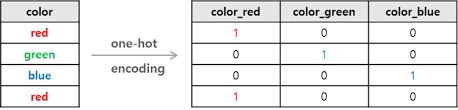

In [108]:
# 위에서 사용한 cust_data_obj 데이터프레임의 내용을 확인해 보겠습니다.
# 성별 컬럼은 라벨인코딩으로 숫자로 매핑 완료 되었으며
# 등급 컬럼은 아직도 문자열로 보여지고 있습니다. 

cust_data_obj.head()

,class,sex,age
0,C,0,28.00
1,E,0,24.00
2,F,0,32.00
3,D,1,18.00
4,C,0,78.00


In [110]:
# pandas에서는 get_dummies함수를 사용하면 쉽게 One-Hot Encording이 가능합니다.
# get_dummies함수를 이용해서 cust_data_obj 데이터프레임의 class 등급 컬럼에 대해서 원핫인코딩을 수행해 보겠습니다.
# 원핫인코딩 결과를 보니, 1개의 등급 컬럼이 5개의 범주 컬럼으로 변환 되었습니다. 
# 5개의 컬럼중에 1개만 1이고, 나머지 0으로 나오게 됩니다. 이게 바로 원핫인코딩 적용 결과입니다.

pd.get_dummies( data=cust_data_obj, columns=[ 'class' ] ).head()

,sex,age,class_C,class_D,class_E,class_F,class_G
0,0,28.00,True,False,False,False,False
1,0,24.00,False,False,True,False,False
2,0,32.00,False,False,False,True,False
3,1,18.00,False,True,False,False,False
4,0,78.00,True,False,False,False,False


### <b>PCA(Principle Component Analysis), 차원축소

차원 축소는 데이터의 차원(특성의 수)을 줄이며 데이터의 중요한 정보를 최대한 보존하는 것을 의미하며     
핵심 원리는 데이터의 분산을 최대화하는 주성분을 찾는 것이다.      
분산은 데이터가 얼마나 특정 방향으로 퍼져 있는지를 나타내며, 큰 분산은 해당 방향에     
데이터의 주요 정보나 패턴이 포함되어 있음을 의미하여 PCA을 통해 주성분을 찾을수 있다.    

In [116]:
# IRIS 붓꽃데이터로 PCA 차원축소 해 보겠습니다.
# 먼저, seaborn에서 iris 데이터셋을 불러와 iris에 저장합니다.

iris = sns.load_dataset('iris')
iris.head(3)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.10,3.50,1.40,0.20,setosa
1,4.90,3.00,1.40,0.20,setosa
2,4.70,3.20,1.30,0.20,setosa


In [118]:
# IRIS 데이터의 species 빼고 나머지 데이터 출력
iris.iloc[:, :-1].head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.10,3.50,1.40,0.20
1,4.90,3.00,1.40,0.20
2,4.70,3.20,1.30,0.20


In [121]:
# PCA 임포트하고 PCA를 2개의 주성분으로 n_components 설정합니다.
# 차원축소를 위해 PCA 수행합니다. 

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_comp = pca.fit_transform(iris.iloc[:, :-1])

In [122]:
# 2개의 주성분을 데이터프레임에 저장하고 출력합니다. 

df_pca = pd.DataFrame(data=pca_comp, columns=['PCA1', 'PCA2'])
df_pca['target'] = iris.species
df_pca

,PCA1,PCA2,target
0,-2.68,0.32,setosa
1,-2.71,-0.18,setosa
2,-2.89,-0.14,setosa
3,-2.75,-0.32,setosa
4,-2.73,0.33,setosa
...,...,...,...
145,1.94,0.19,virginica
146,1.53,-0.38,virginica
147,1.76,0.08,virginica
148,1.90,0.12,virginica


In [124]:
# 2개의 주성분이 얼마나 원본 데이터의 변동성을 반영할수 있는지를
# explained_variance_ratio_ 속성을 통해 알수 있습니다. 
# 첫번째 주성분이 데이터의 변동성을 92% 설명하고 
# 두번째 주성분이 데이터의 변동성을 5% 설명해서 
# 2개를 더하면 데이터의 변동성 95%을 설명합니다.

pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

<br>

<br>

# **[실습1] 데이터 이상치 처리와 Feature Engineering 하기**

cust 데이터의 이상치는 제거하고, 나이는 5단위로 범주화, 평균 요금은 5개 구간으로 나누어 새로운 변수를 만들어 데이터를 저장 해보세요.

* removeOutliers 함수 활용하여 이상치 제거
  * 처리 대상 컬럼 : avg_bill, A_bill, B_bill
* age 컬럼 범주화
  * 나이(age) 0 ~ 4세는 0 ,  5 ~ 9세는 5 ,  10 ~ 14세는 10으로 5단위 범주화
  * 결과를 by_age 컬럼에 저장
* avg_bill 컬럼 범주화
  * 전체 평균 요금(avg_bill)을 균등비율로 low / lowmid / mid / midhigh / high 5단계로 구분
  * 결과를 bill_rating 컬럼에 저장

In [57]:
# 기존에 복사해둔 cust_fix 데이터프레임을 복사합니다. 
cust = cust_fix.copy()

In [58]:
# cust 데이터프레임 내용을 확인해 봅니다.
# 결측치 값들이 보입니다.

cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N


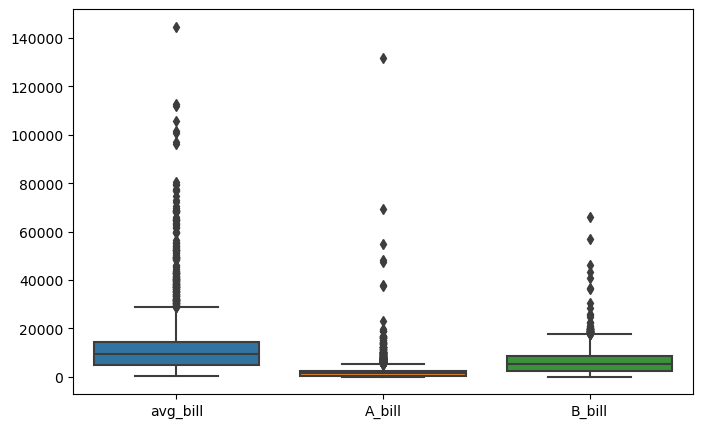

In [59]:
# 'avg_bill','A_bill','B_bill'  컬럼에 대해서 이상치 제거하기전에 시각화를 통해 이상치 확인합니다.
#  seaborn 박스 플랏 그래프를 보니 , 굉장히 큰값들이 존재하는걸로 보입니다. 

import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot( data=cust[ [ 'avg_bill', 'A_bill','B_bill' ] ] )
plt.show()

In [60]:
# 앞에서 만든 removeOutliers 함수를 사용하여 'avg_bill','A_bill','B_bill'  컬럼에 대해서 이상치 제거 합니다.

cust = removeOutliers(cust, 'avg_bill')
cust = removeOutliers(cust, 'A_bill')
cust = removeOutliers(cust, 'B_bill')

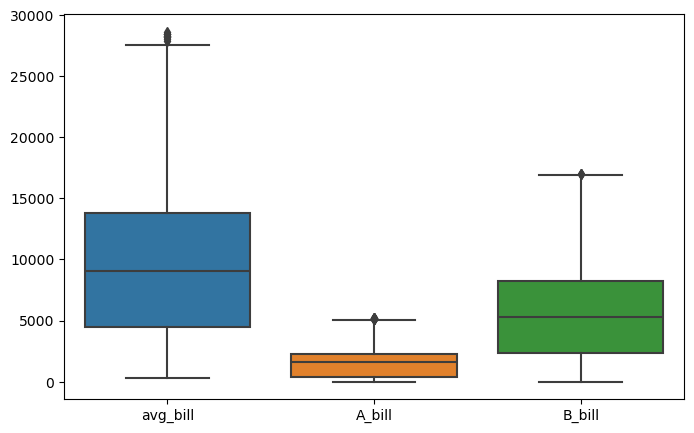

In [62]:
# 'avg_bill','A_bill','B_bill'  컬럼에 대해서 이상치 제거후 시각화를 통해 이상치 확인합니다.
# seaborn 박스 플랏 그래프를 보니 , 이상치가 거의 제거된것을 알수 있습니다. 

import seaborn as sns

plt.figure(figsize=(7,3))
sns.boxplot( data=cust[ [ 'avg_bill', 'A_bill','B_bill' ] ] )
plt.show()

In [63]:
# 나이는 0 ~ 4세는 0 ,  5 ~ 9세는 5 ,  10 ~ 14세는 10으로 5단위 범주화 --> 'by_age' 컬럼에 저장
# astype 함수 사용해서 나이 컬럼의 값들을 정수형으로 만듭니다.

cust['by_age'] = cust[ 'age' ] // 5 * 5
cust = cust.astype({'age': int, 'by_age':int})
cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age
0,C,F,28,0,N,N,2640.00,792.00,1584.00,Y,25
1,E,F,24,1,N,N,16840.00,2526.00,6983.00,N,20
2,F,F,32,1,N,N,15544.73,2331.71,6750.47,N,30
3,D,M,18,1,N,N,4700.00,0.00,4502.00,N,15
4,C,F,78,1,N,N,1361.80,1174.00,0.00,N,75


In [64]:
# 'avg_bill' 평균 요금을 균등비율로 low / lowmid / mid / midhigh / high  5단계로 구분하고 
# bill_rating 컬럼명에 저장하세요.

cust['bill_rating'] = pd.qcut( cust["avg_bill"], 5 , labels=['low','lowmid', 'mid','midhigh','high'])
cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age,bill_rating
0,C,F,28,0,N,N,2640.00,792.00,1584.00,Y,25,low
1,E,F,24,1,N,N,16840.00,2526.00,6983.00,N,20,high
2,F,F,32,1,N,N,15544.73,2331.71,6750.47,N,30,high
3,D,M,18,1,N,N,4700.00,0.00,4502.00,N,15,lowmid
4,C,F,78,1,N,N,1361.80,1174.00,0.00,N,75,low


<br>

# **[실습2] 수업용 데이터에 대해 추가 전처리 하기**

- 'npay' 컬럼을 사이킷런의 LabelEncoder 함수를 사용해서 라벨인코딩 수행하세요.
- 'termination' 컬럼을 판다스의 get_dummies 함수를 활용해서 더미화 하세요. (drop_first=True 옵션 사용)
- cust 데이터프레임에 결측치가 있는지 확인해 보세요.
- 전처리 결과를 'cust_data.csv' 파일로 저장하세요.

In [135]:
# 기존에 복사해둔 cust_fix 데이터프레임을 복사합니다. 
cust = cust_fix.copy()

In [136]:
# cust 데이터프레임 내용을 확인해 봅니다.
# 결측치 값들이 보입니다.

cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N


In [137]:
# 'npay' 컬럼을 사이킷런의 LabelEncoder 함수를 사용해서 라벨인코딩 수행하세요.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cust[ 'npay' ] = le.fit_transform(cust[ 'npay' ])
cust

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,0,2640.00,792.00,1584.00,Y
1,E,F,24.00,1,N,0,16840.00,2526.00,6983.00,N
2,F,F,32.00,1,N,0,15544.73,2331.71,6750.47,N
3,D,M,18.00,1,N,0,4700.00,0.00,4502.00,N
4,C,F,78.00,1,N,0,1361.80,1174.00,0.00,N
...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.00,1,N,0,1860.00,1716.00,0.00,N
8224,C,F,15.00,1,N,1,1296.10,194.41,643.10,N
8225,G,M,12.00,1,N,0,13799.67,2069.95,10605.93,N
8226,C,F,40.00,0,N,0,3140.00,942.00,1884.00,Y


In [138]:
# 'termination' 컬럼을 판다스의 get_dummies 함수를 활용해서 더미화 하세요. 
# drop_first=True 옵션 사용하지 않았으며, 
# termination 컬럼이 termination_N, termination_Y 2개로 원핫인코딩 확인할수 있음.
# 판다스 버젼업이 되면서 0, 1로 표시 안되고 True, False 표기되어 dtype='int' 사용함.

pd.get_dummies( data=cust, columns=[ 'termination' ] , dtype='int')

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination_N,termination_Y
0,C,F,28.00,0,N,0,2640.00,792.00,1584.00,0,1
1,E,F,24.00,1,N,0,16840.00,2526.00,6983.00,1,0
2,F,F,32.00,1,N,0,15544.73,2331.71,6750.47,1,0
3,D,M,18.00,1,N,0,4700.00,0.00,4502.00,1,0
4,C,F,78.00,1,N,0,1361.80,1174.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.00,1,N,0,1860.00,1716.00,0.00,1,0
8224,C,F,15.00,1,N,1,1296.10,194.41,643.10,1,0
8225,G,M,12.00,1,N,0,13799.67,2069.95,10605.93,1,0
8226,C,F,40.00,0,N,0,3140.00,942.00,1884.00,0,1


In [139]:
# 'termination' 컬럼을 판다스의 get_dummies 함수를 활용해서 더미화 하세요. (drop_first=True 옵션 사용)
# termination 컬럼이 termination_N, termination_Y 2개로 원핫인코딩 되지만
# drop_first=True 옵션 사용으로 첫번째 생성된 termination_N 컬럼이 삭제되어 termination_Y 컬럼만 남음.

cust = pd.get_dummies( data=cust, columns=[ 'termination' ], drop_first=True, )
cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination_Y
0,C,F,28.00,0,N,0,2640.00,792.00,1584.00,1
1,E,F,24.00,1,N,0,16840.00,2526.00,6983.00,0
2,F,F,32.00,1,N,0,15544.73,2331.71,6750.47,0
3,D,M,18.00,1,N,0,4700.00,0.00,4502.00,0
4,C,F,78.00,1,N,0,1361.80,1174.00,0.00,0


In [140]:
# cust 데이터프레임에 결측치가 있는지 확인해 보세요.
cust.isna().sum()

class            0
sex              0
age              0
service          0
stop             0
npay             0
avg_bill         0
A_bill           0
B_bill           0
termination_Y    0
dtype: int64

In [141]:
# cust_data 데이터프레임을 'cust_data.csv' 파일로 저장해 보겠습니다. 
cust.to_csv('cust_data.csv', index=False)

<br>

## 정리

데이터 전처리의 두번째 파트을 살펴 보았습니다.  
- 이상치는 특정 추세에서 크게 벗어난 데이터 혹은 중앙값을 크게 벗어난 데이터를 의미하며    
- value_counts 함수나, boxplot 그래프를 활용하여 이상치 파악후 이상치 삭제나 대체하는 방법을 사용합니다. 
- Feature Engineering은 모델 정확도를 높이기 위해서 주어진 데이터를 잘 표현할 수 있는 features로 변형시키는 과정이며       
- 데이터의 도메인 지식을 활용해 feature를 만드는 과정입니다.     
- Feature Engineering 하는 방법에는 bining 구간화 , 스케일링, 라벨인코딩, 원핫인코딩등의 그외에도 많은 방법이 존재할수 있습니다.           
- 데이터 전처리 파트가 생각보다 쉽지 않고 알아야 될것이 너무 많았습니다.    
- 어렵겠지만, 투자한 시간만큼 여러분의 역량도 같이 성장할수 있으므로 시간을 가지고 꾸준히 연습해 주시기 바랍니다. 